<a href="https://colab.research.google.com/github/ElihuIzanami/Aprendizaje-No-Supervisado/blob/main/Elihu_Montoya_Estrada_Challenge_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Challenge

Considera los datos `creditcard.csv`. Los puedes encontrar [aquí](https://drive.google.com/file/d/1jqZ6--OOGk477xv_yxqyell8RBtlOXL8/view?usp=drive_link)

Como contexto, estos datos fueron obtenidos del siguiente enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Consejo: Lee atentamente la descripción del dataset y el significado de las columnas en el enlace anterior.


## Realiza lo siguiente
1. Entrena un modelo con KMeans, recuerda separar la columna objetivo `Class` del resto de las columnas.
2. Identifica la mejor K utilizando el método del codo y el método de las siluetas.
3. Añade una columna llamada `cluster` etiquetando el set de prueba (30% de los datos).
4. Identifica el grupo al que pertenecen los datos cuyo `Class` es igual a 1. ¿Pertenecen a un solo grupo o a varios?

El dataset que se ocupo para el Proyecto : Introduccion al analisis Estadistico se descargo de la pagina de www.kaggle.com a continuación se enlista la url donde se descargo dicho archivo .cvs https://drive.google.com/file/d/1jqZ6--OOGk477xv_yxqyell8RBtlOXL8/view

In [7]:
#Importar librebrias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [8]:
# 1. Importar datos desde Google Colab cargar el datset
ruta = '/content/creditcard.csv'
df_creditcard = pd.read_csv(ruta)

df_creditcard

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [9]:
df_creditcard.shape

(284807, 31)

In [10]:
# Obtenermos la información del dataset
df_creditcard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
# Separar características (X) y la variable objetivo (Class)
X = df_creditcard.drop(columns=['Class'])
y = df_creditcard['Class']

In [12]:
# 2. Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [13]:
# 3. Escalar los datos (esencial para KMeans, especialmente por Time y Amount)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# --- IDENTIFICACIÓN DE LA MEJOR K ---
# Usaremos una muestra del set de entrenamiento para acelerar el cálculo de la silueta
np.random.seed(42)
sample_idx = np.random.choice(X_train_scaled.shape[0], size=10000, replace=False)
X_train_sample = X_train_scaled[sample_idx]

inercias = []
siluetas = []
k_valores = range(2, 7)  # Evaluamos de 2 a 6 clústeres

In [15]:
for k in k_valores:
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_eval.fit(X_train_scaled) # Inercia con todo el set de entrenamiento
    inercias.append(kmeans_eval.inertia_)

    # Silueta solo con la muestra por costo computacional
    labels_sample = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_train_sample)
    score = silhouette_score(X_train_sample, labels_sample)
    siluetas.append(score)

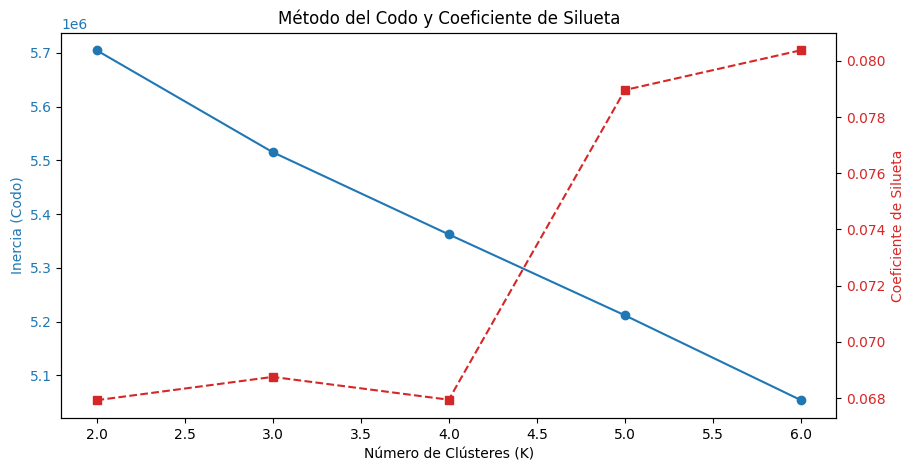

In [16]:
# Graficar Método del Codo y de la Silueta
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia (Codo)', color='tab:blue')
ax1.plot(k_valores, inercias, marker='o', color='tab:blue', label='Inercia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Coeficiente de Silueta', color='tab:red')
ax2.plot(k_valores, siluetas, marker='s', color='tab:red', linestyle='--', label='Silueta')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Método del Codo y Coeficiente de Silueta')
plt.show()

In [17]:
# Entrenar el modelo final con K = 3
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(X_train_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [18]:
# Predecir los clústeres en el set de prueba (30%)
test_clusters = kmeans_final.predict(X_test_scaled)

In [19]:
# Crear el dataframe de prueba con la nueva columna y la clase original
df_test_resultados = pd.DataFrame(X_test).copy()
df_test_resultados['cluster'] = test_clusters
df_test_resultados['Class'] = y_test.values

In [20]:
print("Primeras filas del set de prueba etiquetado:")
print(df_test_resultados[['cluster', 'Class']].head())

Primeras filas del set de prueba etiquetado:
        cluster  Class
186882        1      0
165754        1      0
235285        1      0
101271        0      0
5832          0      0


In [21]:
# Filtrar solo los fraudes del set de prueba
fraudes_test = df_test_resultados[df_test_resultados['Class'] == 1]

In [22]:
# Contar cuántos fraudes caen en cada clúster
distribucion_fraudes = fraudes_test['cluster'].value_counts().sort_index()

In [23]:
print("\n--- Distribución de los casos de fraude por Clúster ---")
for cluster, count in distribucion_fraudes.items():
    porcentaje = (count / len(fraudes_test)) * 100
    print(f"Clúster {cluster}: {count} fraudes ({porcentaje:.2f}%)")


--- Distribución de los casos de fraude por Clúster ---
Clúster 0: 95 fraudes (64.19%)
Clúster 1: 51 fraudes (34.46%)
Clúster 2: 2 fraudes (1.35%)
